# 🔬 Transformer-CNN-LSTM Fall Detection
## IWR6843AOP FMCW Radar — 6-Class Activity Classification

**Target**: Exceed the reference paper's CNN-LSTM (99.65% val accuracy, 98.3% F1)

### Setup Instructions:
1. **Enable GPU**: Runtime → Change runtime type → T4 GPU
2. **Upload dataset zip to Google Drive** ✅ (already done)
3. **Run all cells** in order

## 1. Setup & Dependencies

In [ ]:
# Check GPU availability
!nvidia-smi

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Sun Mar 15 15:51:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install scikit-learn seaborn -q

## 2. Mount Drive & Extract Dataset Zip

This cell mounts your Google Drive, finds the dataset zip, and extracts it to Colab's local storage (much faster than reading from Drive directly).

In [ ]:
from google.colab import drive
import os, zipfile, subprocess, glob as glib

# Mount Google Drive
drive.mount('/content/drive')

# =====================================================
# Find the dataset zip in Drive
# =====================================================
zip_path = None

# Common locations to check
candidates = [
    '/content/drive/MyDrive/dataset_26_09_25.zip',
    '/content/drive/MyDrive/data_set_26_09_25.zip',
]

for c in candidates:
    if os.path.isfile(c):
        zip_path = c
        break

# If not found, search for it
if zip_path is None:
    print('Searching Drive for the zip file...')
    result = subprocess.run(
        ['find', '/content/drive/MyDrive', '-maxdepth', '3', '-name', '*dataset*26*09*25*.zip', '-type', 'f'],
        capture_output=True, text=True, timeout=60
    )
    if result.stdout.strip():
        found = result.stdout.strip().split('\n')
        zip_path = found[0]
        print(f'Found: {found}')
    else:
        # Try broader search
        result2 = subprocess.run(
            ['find', '/content/drive/MyDrive', '-maxdepth', '3', '-name', '*.zip', '-type', 'f'],
            capture_output=True, text=True, timeout=60
        )
        if result2.stdout.strip():
            zips = result2.stdout.strip().split('\n')
            print(f'Found these zip files — set zip_path to the correct one:')
            for z in zips:
                size_mb = os.path.getsize(z) / 1024 / 1024
                print(f'  {z}  ({size_mb:.1f} MB)')
            zip_path = zips[0]  # default to first one
        else:
            print('❌ No zip files found in Drive. Upload and re-run.')

if zip_path:
    size_mb = os.path.getsize(zip_path) / 1024 / 1024
    print(f'\n✓ Using zip: {zip_path} ({size_mb:.1f} MB)')
    print('Extracting... (this may take a minute)')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content/')
    print('✓ Extraction complete!')

    # Find the actual dataset root (handles nested folders)
    result = subprocess.run(
        ['find', '/content', '-maxdepth', '5', '-type', 'd', '-name', 'Sitting_chair'],
        capture_output=True, text=True, timeout=30
    )
    if result.stdout.strip():
        sitting_dir = result.stdout.strip().split('\n')[0]
        DATASET_ROOT = os.path.dirname(sitting_dir)
        print(f'\n✓ Dataset root: {DATASET_ROOT}')
        print(f'  Classes: {sorted(os.listdir(DATASET_ROOT))}')
    else:
        print('\n⚠ Could not find class folders. Listing extracted contents:')
        !ls -la /content/
        DATASET_ROOT = '/content/dataset_26_09_25/dataset_26_09_25'  # fallback

Mounted at /content/drive

✓ Using zip: /content/drive/MyDrive/dataset_26_09_25.zip (91.8 MB)
Extracting... (this may take a minute)
✓ Extraction complete!

✓ Dataset root: /content/dataset_26_09_25
  Classes: ['Sitting_chair', 'Stand_Sit_chair_transition', 'Standing_walk', 'chair_floor_transition', 'sitting_floor', 'stand_floor_transition']


## 3. Data Pipeline

In [ ]:
import os
import json
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings("ignore")

# ---- Constants ----
CLASSES = [
    "stand_floor_transition",      # 0 — fall
    "chair_floor_transition",      # 1 — fall
    "Sitting_chair",               # 2 — non-fall
    "Standing_walk",               # 3 — non-fall
    "sitting_floor",               # 4 — non-fall
    "Stand_Sit_chair_transition",  # 5 — non-fall
]
FALL_CLASSES = {0, 1}
NON_FALL_CLASSES = {2, 3, 4, 5}
WINDOW_SIZE = 40
STRIDE = 5
SNR_THRESHOLD = 10.0
NUM_FEATURES = 12
FRAME_DT = 0.055

print(f"Classes: {CLASSES}")
print(f"Fall classes: {[CLASSES[i] for i in FALL_CLASSES]}")
print(f"Window: {WINDOW_SIZE} frames, Stride: {STRIDE}")

Classes: ['stand_floor_transition', 'chair_floor_transition', 'Sitting_chair', 'Standing_walk', 'sitting_floor', 'Stand_Sit_chair_transition']
Fall classes: ['stand_floor_transition', 'chair_floor_transition']
Window: 40 frames, Stride: 5


In [ ]:
def extract_frame_features(point_cloud, prev_velocity=None):
    """Extract 12-dim feature vector from a single radar frame."""
    if not point_cloud or len(point_cloud) == 0:
        feat = np.zeros(NUM_FEATURES, dtype=np.float32)
        return feat, np.zeros(3, dtype=np.float32)

    pts = np.array(point_cloud, dtype=np.float32)

    # SNR filter (column 4)
    if pts.shape[1] > 4:
        snr_mask = pts[:, 4] >= SNR_THRESHOLD
        if snr_mask.sum() > 0:
            pts = pts[snr_mask]

    n_points = len(pts)
    x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]
    doppler = pts[:, 3] if pts.shape[1] > 3 else np.zeros(n_points)

    # Centroid
    x_mean, y_mean, z_mean = x.mean(), y.mean(), z.mean()

    # Velocity decomposition from radial Doppler
    r = np.sqrt(x_mean**2 + y_mean**2 + z_mean**2) + 1e-8
    vx_mean = doppler.mean() * (x_mean / r)
    vy_mean = doppler.mean() * (y_mean / r)
    vz_mean = doppler.mean() * (z_mean / r)

    current_velocity = np.array([vx_mean, vy_mean, vz_mean], dtype=np.float32)

    # Acceleration
    acc = (current_velocity - prev_velocity) / FRAME_DT if prev_velocity is not None else np.zeros(3, dtype=np.float32)

    # Point statistics
    spread_xy = np.sqrt(x.var() + y.var()) if n_points > 1 else 0.0
    height_range = z.max() - z.min() if n_points > 1 else 0.0

    feat = np.array([
        x_mean, y_mean, z_mean,
        vx_mean, vy_mean, vz_mean,
        acc[0], acc[1], acc[2],
        float(n_points), spread_xy, height_range
    ], dtype=np.float32)

    return feat, current_velocity


def extract_recording_features(frames):
    """Process all frames in a recording → (T, 12) array."""
    features = []
    prev_vel = None
    for frame_obj in frames:
        fd = frame_obj.get("frameData", frame_obj)
        pc = fd.get("pointCloud", [])
        feat, prev_vel = extract_frame_features(pc, prev_vel)
        features.append(feat)
    return np.array(features, dtype=np.float32)


def create_windows(features, label, window_size=WINDOW_SIZE, stride=STRIDE):
    """Sliding window over a recording."""
    T = len(features)
    samples = []
    if T < window_size:
        padded = np.zeros((window_size, features.shape[1]), dtype=np.float32)
        padded[window_size - T:] = features
        samples.append((padded, label))
    else:
        for start in range(0, T - window_size + 1, stride):
            window = features[start:start + window_size]
            samples.append((window, label))
    return samples


def augment_window(window, noise_std=0.02, time_warp_prob=0.3):
    """Gaussian noise + time warping augmentation."""
    aug = window.copy()
    aug += np.random.randn(*aug.shape).astype(np.float32) * noise_std

    if np.random.rand() < time_warp_prob:
        T = aug.shape[0]
        warp_factor = np.random.uniform(0.8, 1.2)
        new_len = int(T * warp_factor)
        if new_len > 2:
            indices = np.linspace(0, T - 1, new_len).astype(int)
            warped = aug[indices]
            if len(warped) >= T:
                aug = warped[:T]
            else:
                padded = np.zeros_like(aug)
                padded[:len(warped)] = warped
                padded[len(warped):] = warped[-1]
                aug = padded
    return aug

print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


In [ ]:
class RadarFallDataset(Dataset):
    def __init__(self, windows, labels, scaler=None, augment=False):
        self.augment = augment
        X = np.array(windows, dtype=np.float32)
        y = np.array(labels, dtype=np.int64)
        N, W, F = X.shape

        if scaler is None:
            self.scaler = StandardScaler()
            X_flat = X.reshape(-1, F)
            X_flat = self.scaler.fit_transform(X_flat)
            X = X_flat.reshape(N, W, F)
        else:
            self.scaler = scaler
            X_flat = X.reshape(-1, F)
            X_flat = self.scaler.transform(X_flat)
            X = X_flat.reshape(N, W, F)

        self.X = X.astype(np.float32)
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            x = augment_window(x)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

print("✓ Dataset class defined")

✓ Dataset class defined


In [ ]:
# ===== LOAD ALL DATA =====

all_windows = []
all_labels = []
class_counts = {}

for label_idx, class_name in enumerate(CLASSES):
    class_dir = os.path.join(DATASET_ROOT, class_name)
    if not os.path.isdir(class_dir):
        print(f"  [WARN] Not found: {class_dir}")
        continue

    json_files = sorted(glob.glob(os.path.join(class_dir, "*.json")))
    class_counts[class_name] = 0

    for jf in json_files:
        try:
            with open(jf, 'r') as f:
                recording = json.load(f)
        except (json.JSONDecodeError, IOError):
            continue

        frames = recording.get("data", [])
        if len(frames) < 5:
            continue

        features = extract_recording_features(frames)
        windows = create_windows(features, label_idx)

        for w, l in windows:
            all_windows.append(w)
            all_labels.append(l)
            class_counts[class_name] += 1

print(f"\n{'='*50}")
print(f"Dataset Summary")
print(f"{'='*50}")
for cls, cnt in class_counts.items():
    print(f"  {cls:35s}: {cnt:6d} windows")
print(f"  {'TOTAL':35s}: {sum(class_counts.values()):6d} windows")
print(f"{'='*50}")


Dataset Summary
  stand_floor_transition             :    741 windows
  chair_floor_transition             :    728 windows
  Sitting_chair                      :   1430 windows
  Standing_walk                      :   1417 windows
  sitting_floor                      :   1430 windows
  Stand_Sit_chair_transition         :    715 windows
  TOTAL                              :   6461 windows


In [ ]:
# ===== TRAIN / VAL / TEST SPLIT =====

windows_arr = np.array(all_windows, dtype=np.float32)
labels_arr = np.array(all_labels, dtype=np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    windows_arr, labels_arr, test_size=0.30, stratify=labels_arr, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")

# Build datasets
train_ds = RadarFallDataset(X_train, y_train, scaler=None, augment=True)
val_ds = RadarFallDataset(X_val, y_val, scaler=train_ds.scaler, augment=False)
test_ds = RadarFallDataset(X_test, y_test, scaler=train_ds.scaler, augment=False)

# Class weights
unique, counts = np.unique(y_train, return_counts=True)
total = counts.sum()
class_weights = torch.tensor([total / (len(unique) * c) for c in counts], dtype=torch.float32)
print(f"Class weights: {[f'{w:.3f}' for w in class_weights.tolist()]}")

# Weighted sampler
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(sample_weights.tolist(), len(y_train), replacement=True)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Save scaler
with open('/content/scaler.pkl', 'wb') as f:
    pickle.dump(train_ds.scaler, f)

# Quick sanity check
for X_batch, y_batch in train_loader:
    print(f"\nBatch shapes: X={X_batch.shape}, y={y_batch.shape}")
    print(f"Labels in batch: {y_batch.unique().tolist()}")
    break

print("\n✓ Data pipeline ready")

Train: 4522, Val: 969, Test: 970
Class weights: ['1.452', '1.481', '0.753', '0.760', '0.753', '1.507']

Batch shapes: X=torch.Size([64, 40, 12]), y=torch.Size([64])
Labels in batch: [0, 1, 2, 3, 4, 5]

✓ Data pipeline ready


## 4. Model Architecture — Transformer-CNN-LSTM

In [ ]:
import math
import torch.nn as nn
import torch.nn.functional as F


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.query = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        attn_weights = torch.softmax(self.query(x), dim=1)
        return (attn_weights * x).sum(dim=1)


class TransformerCNNLSTM(nn.Module):
    def __init__(self, num_features=12, num_classes=6, d_model=64, nhead=4,
                 num_encoder_layers=2, cnn_filters=128, cnn_kernel=3,
                 lstm_hidden=128, dropout=0.4):
        super().__init__()

        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout * 0.5)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout * 0.5, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.transformer_norm = nn.LayerNorm(d_model)

        self.cnn = nn.Sequential(
            nn.Conv1d(d_model, cnn_filters, kernel_size=cnn_kernel, padding=cnn_kernel // 2),
            nn.BatchNorm1d(cnn_filters), nn.GELU(),
            nn.Conv1d(cnn_filters, cnn_filters, kernel_size=cnn_kernel, padding=cnn_kernel // 2),
            nn.BatchNorm1d(cnn_filters), nn.GELU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden,
                           num_layers=2, batch_first=True, bidirectional=True,
                           dropout=dropout * 0.5)

        self.attention_pool = AttentionPooling(lstm_hidden * 2)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * 2, 128), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                if 'lstm' in name:
                    nn.init.orthogonal_(param)
                else:
                    nn.init.kaiming_normal_(param, nonlinearity='relu')
            elif 'bias' in name:
                nn.init.zeros_(param)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = self.transformer_norm(x)
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm(x)
        x = self.attention_pool(x)
        return self.classifier(x)

    def predict_proba(self, x):
        return F.softmax(self.forward(x), dim=-1)


# Instantiate
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerCNNLSTM(num_features=12, num_classes=6).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(f"Device: {DEVICE}")

# Quick test
dummy = torch.randn(4, 40, 12).to(DEVICE)
out = model(dummy)
print(f"Forward pass: {dummy.shape} → {out.shape}")
print("\n✓ Model ready")

Model parameters: 868,807
Device: cuda
Forward pass: torch.Size([4, 40, 12]) → torch.Size([4, 6])

✓ Model ready


## 5. Training

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

# ---- Training functions ----
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

print("✓ Training functions defined")

✓ Training functions defined


In [ ]:
# ===== TRAINING LOOP =====

EPOCHS = 150
LR = 1e-3
PATIENCE = 15

criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.05)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_acc = 0.0
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>10} | {'Val Acc':>8} | {'LR':>10}")
print("-" * 75)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:6d} | {train_loss:10.4f} | {train_acc:8.2%} | {val_loss:10.4f} | {val_acc:7.2%} | {lr:10.6f}", end="")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, '/content/best_model.pth')
        print(f"  ★ Best")
    else:
        patience_counter += 1
        print()

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed:.1f}s")
print(f"Best validation accuracy: {best_val_acc:.4%}")

 Epoch | Train Loss | Train Acc |   Val Loss |  Val Acc |         LR
---------------------------------------------------------------------------
     1 |     0.8753 |   73.24% |     0.6518 |  85.04% |   0.001000  ★ Best
     2 |     0.6536 |   83.48% |     0.6345 |  86.89% |   0.001000  ★ Best
     3 |     0.5954 |   85.67% |     0.5014 |  91.02% |   0.000999  ★ Best
     4 |     0.5698 |   88.24% |     0.5407 |  89.68% |   0.000998
     5 |     0.5330 |   88.54% |     0.5164 |  89.27% |   0.000997
     6 |     0.5044 |   90.29% |     0.5018 |  90.30% |   0.000996
     7 |     0.4896 |   90.69% |     0.5414 |  90.71% |   0.000995
     8 |     0.4955 |   89.85% |     0.4728 |  92.67% |   0.000993  ★ Best
     9 |     0.4793 |   90.65% |     0.5736 |  87.10% |   0.000991
    10 |     0.4380 |   92.22% |     0.4597 |  92.57% |   0.000989
    11 |     0.4285 |   92.72% |     0.4881 |  91.43% |   0.000987
    12 |     0.4354 |   92.39% |     0.4432 |  95.15% |   0.000984  ★ Best
    13 |   

## 6. Training Curves

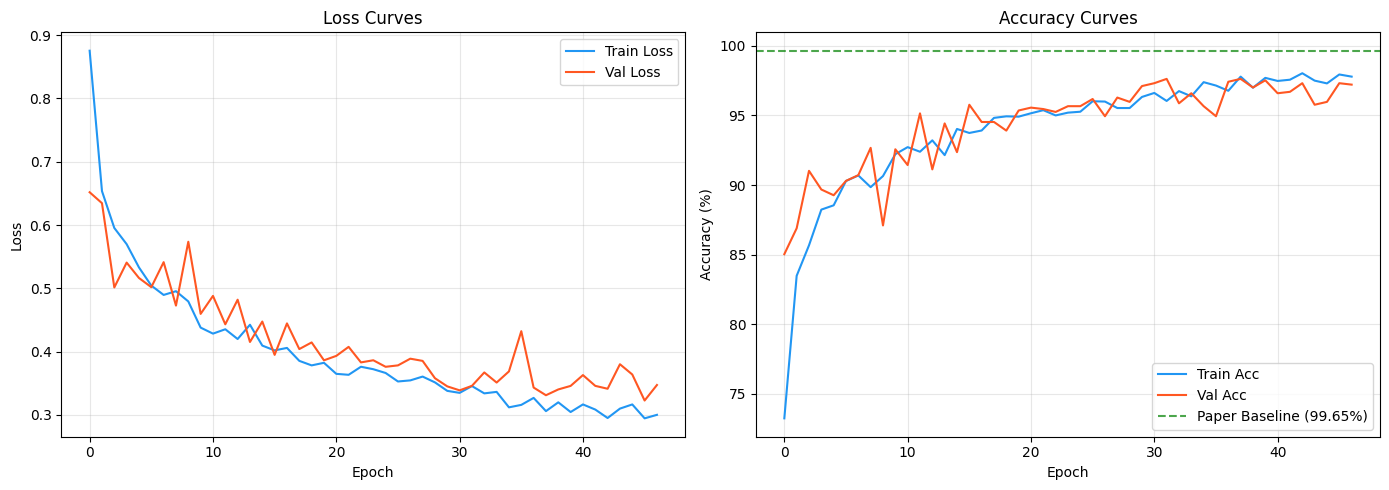

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', color='#2196F3')
ax1.plot(history['val_loss'], label='Val Loss', color='#FF5722')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot([a*100 for a in history['train_acc']], label='Train Acc', color='#2196F3')
ax2.plot([a*100 for a in history['val_acc']], label='Val Acc', color='#FF5722')
ax2.axhline(y=99.65, color='green', linestyle='--', alpha=0.7, label='Paper Baseline (99.65%)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Final Evaluation on Test Set

In [ ]:
# Load best model
checkpoint = torch.load('/content/best_model.pth', map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (val_acc={checkpoint['val_acc']:.4%})")

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, DEVICE)

print(f"\n{'='*60}")
print(f"  FINAL TEST RESULTS — 6-CLASS")
print(f"{'='*60}")
print(f"\nTest Accuracy: {test_acc:.4%}")
print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

Loaded best model from epoch 32 (val_acc=97.6264%)

  FINAL TEST RESULTS — 6-CLASS

Test Accuracy: 96.8041%

Classification Report:
                            precision    recall  f1-score   support

    stand_floor_transition     0.9340    0.8919    0.9124       111
    chair_floor_transition     0.9273    0.9358    0.9315       109
             Sitting_chair     0.9862    1.0000    0.9931       215
             Standing_walk     0.9810    0.9718    0.9764       213
             sitting_floor     0.9860    0.9860    0.9860       215
Stand_Sit_chair_transition     0.9455    0.9720    0.9585       107

                  accuracy                         0.9680       970
                 macro avg     0.9600    0.9596    0.9597       970
              weighted avg     0.9679    0.9680    0.9679       970



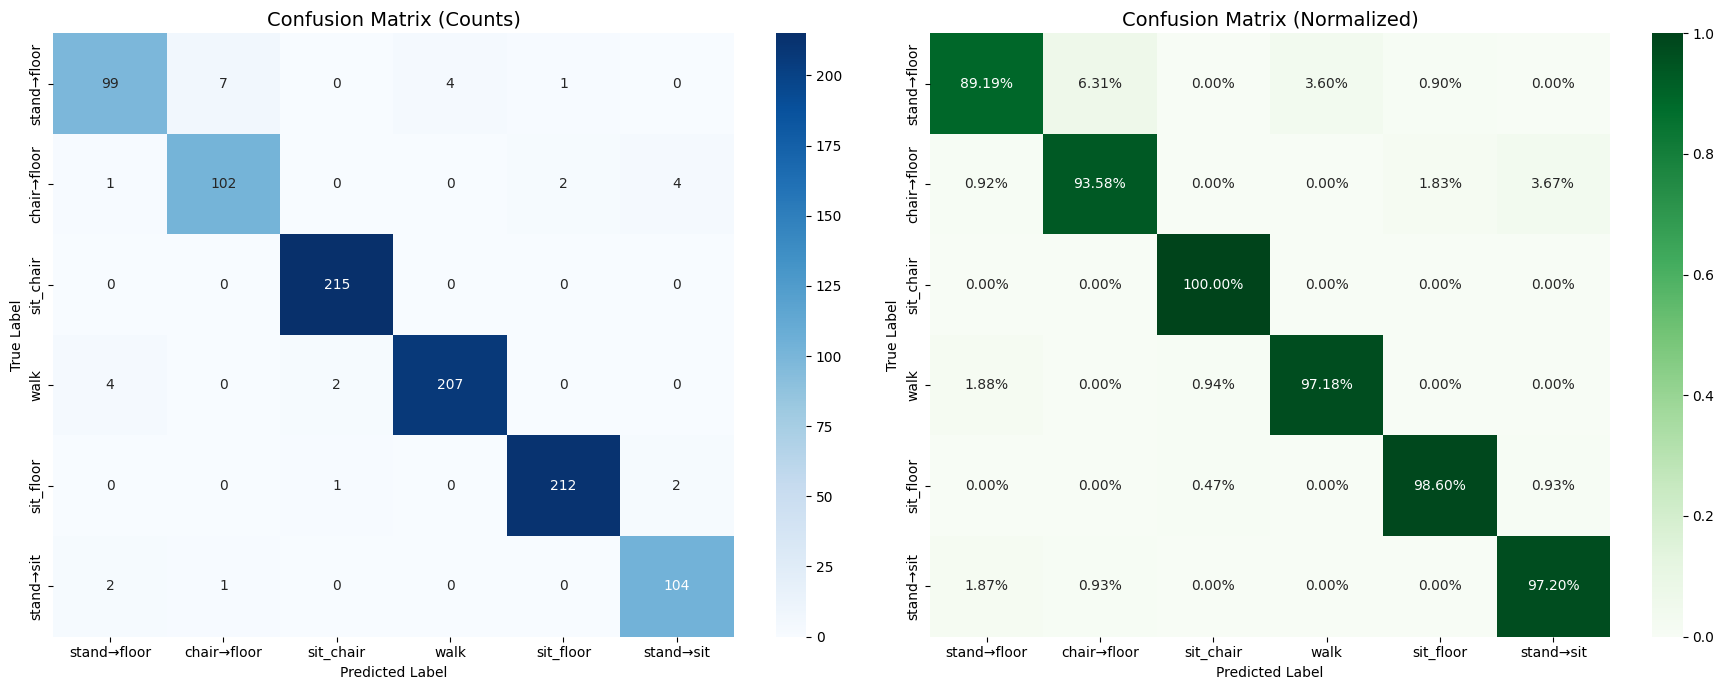

In [ ]:
# Confusion Matrix Visualization
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

short_names = ['stand→floor', 'chair→floor', 'sit_chair', 'walk', 'sit_floor', 'stand→sit']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=short_names,
            yticklabels=short_names, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontsize=14)
ax1.set_ylabel('True Label'); ax1.set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', xticklabels=short_names,
            yticklabels=short_names, ax=ax2)
ax2.set_title('Confusion Matrix (Normalized)', fontsize=14)
ax2.set_ylabel('True Label'); ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ===== PAPER COMPARISON — Binary Fall vs Non-Fall =====

binary_preds = np.array([0 if p in FALL_CLASSES else 1 for p in test_preds])
binary_labels = np.array([0 if l in FALL_CLASSES else 1 for l in test_labels])

binary_acc = accuracy_score(binary_labels, binary_preds)
binary_f1 = f1_score(binary_labels, binary_preds, average='binary', pos_label=0)

print(f"{'='*60}")
print(f"  PAPER COMPARISON — Binary: Fall vs Non-Fall")
print(f"{'='*60}")
print(f"                        Ours        Paper")
print(f"  Binary Accuracy:   {binary_acc:8.4%}     99.65%")
print(f"  Binary F1-Score:   {binary_f1:8.4%}     98.30%")
print(f"  6-Class Accuracy:  {test_acc:8.4%}     N/A")
print(f"{'='*60}")

if binary_acc > 0.9965:
    print("\n🎉 EXCEEDED paper's validation accuracy!")
if binary_f1 > 0.983:
    print("🎉 EXCEEDED paper's F1-score!")

  PAPER COMPARISON — Binary: Fall vs Non-Fall
                        Ours        Paper
  Binary Accuracy:   98.1443%     99.65%
  Binary F1-Score:   95.8716%     98.30%
  6-Class Accuracy:  96.8041%     N/A


## 8. Save Model to Google Drive & Download

In [ ]:
import shutil

# Save to Google Drive (persistent — won't be lost when Colab disconnects)
drive_save_dir = '/content/drive/MyDrive/fall_detection_model'
os.makedirs(drive_save_dir, exist_ok=True)

shutil.copy('/content/best_model.pth', drive_save_dir)
shutil.copy('/content/scaler.pkl', drive_save_dir)
shutil.copy('/content/training_curves.png', drive_save_dir)
shutil.copy('/content/confusion_matrix.png', drive_save_dir)

print(f"✓ Saved to Google Drive: {drive_save_dir}")
print(f"  Files: {os.listdir(drive_save_dir)}")
print()
print("You can also download directly:")

# Also offer direct download
from google.colab import files
files.download('/content/best_model.pth')
files.download('/content/scaler.pkl')

✓ Saved to Google Drive: /content/drive/MyDrive/fall_detection_model
  Files: ['best_model.pth', 'scaler.pkl', 'training_curves.png', 'confusion_matrix.png']

You can also download directly:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Inference Smoke Test (Optional)

In [ ]:
# Quick inference test on a few recordings from each class
from collections import Counter

model.eval()
results_summary = []

for cls_idx, cls_name in enumerate(CLASSES):
    class_dir = os.path.join(DATASET_ROOT, cls_name)
    json_files = sorted(glob.glob(os.path.join(class_dir, "*.json")))[:3]

    for jf in json_files:
        with open(jf, 'r') as f:
            recording = json.load(f)

        frames = recording.get("data", [])
        features = extract_recording_features(frames)

        if len(features) < WINDOW_SIZE:
            continue

        # Take windows
        preds_for_file = []
        for start in range(0, len(features) - WINDOW_SIZE + 1, STRIDE):
            window = features[start:start + WINDOW_SIZE]
            window_norm = train_ds.scaler.transform(window.reshape(-1, NUM_FEATURES)).reshape(1, WINDOW_SIZE, NUM_FEATURES)
            x_t = torch.tensor(window_norm, dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                probs = model.predict_proba(x_t)[0].cpu().numpy()
            preds_for_file.append(CLASSES[probs.argmax()])

        most_common = Counter(preds_for_file).most_common(1)[0]
        correct = most_common[0] == cls_name
        results_summary.append(correct)
        status = '✓' if correct else '✗'
        print(f"  {status} {os.path.basename(jf):20s} | True: {cls_name:30s} | Pred: {most_common[0]:30s} ({most_common[1]}/{len(preds_for_file)})")

overall = sum(results_summary) / len(results_summary) * 100
print(f"\nInference accuracy: {overall:.1f}% ({sum(results_summary)}/{len(results_summary)} files correct)")

  ✓ replay_1.json        | True: stand_floor_transition         | Pred: stand_floor_transition         (13/13)
  ✓ replay_10.json       | True: stand_floor_transition         | Pred: stand_floor_transition         (13/13)
  ✓ replay_11.json       | True: stand_floor_transition         | Pred: stand_floor_transition         (13/13)
  ✓ replay_1.json        | True: chair_floor_transition         | Pred: chair_floor_transition         (11/13)
  ✓ replay_10.json       | True: chair_floor_transition         | Pred: chair_floor_transition         (13/13)
  ✓ replay_11.json       | True: chair_floor_transition         | Pred: chair_floor_transition         (13/13)
  ✓ replay_1.json        | True: Sitting_chair                  | Pred: Sitting_chair                  (12/13)
  ✓ replay_10.json       | True: Sitting_chair                  | Pred: Sitting_chair                  (13/13)
  ✓ replay_100.json      | True: Sitting_chair                  | Pred: Sitting_chair                  (13/13)
 